In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.transform import Rotation
from torch_fourier_slice.project import project_3d_to_2d

from panther_em.coordinates import OffsetPolarTransform
from simulate_volume import simulate_volume

## Load in volume to take projections from

This is just an example PDB file. You can replace it with your favorite structure to simulate

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00007myi.cif

--2026-07-16 10:54:33--  https://files.rcsb.org/download/pdb_00007myi.cif
Resolving files.rcsb.org (files.rcsb.org)... 65.8.180.80, 65.8.180.116, 65.8.180.93, ...
Connecting to files.rcsb.org (files.rcsb.org)|65.8.180.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [chemical/x-cif]
Saving to: ‘pdb_00007myi.cif’

pdb_00007myi.cif        [ <=>                ]   1.32M  --.-KB/s    in 0.04s   

2026-07-16 10:54:33 (31.6 MB/s) - ‘pdb_00007myi.cif’ saved [1389352]



In [3]:
pdb_path = "pdb_00007myi.cif"

### Simulate the volume

Uses the `simulate_volume` helper (see `simulate_volume.py`), a thin wrapper around `ttsim3d` that returns a `numpy.ndarray` volume directly. These parameters have significance if you're trying to match the expected projections in some experimental dataset. However, these parameters are plausible and produce nice, centered projections.

In [4]:
volume = simulate_volume(
    pdb_path=pdb_path,
    pixel_spacing=0.8,  # Angstroms
    volume_shape=(256, 256, 256),
    voltage=300.0,  # in keV
    dose_start=0.0,  # in e-/A^2
    dose_end=15.0,  # in e-/A^2
    b_factor_scaling=1.0,
    additional_b_factor=0.0,
)
print(type(volume), volume.shape, volume.dtype)

<class 'numpy.ndarray'> (256, 256, 256) float32


## Setup orientation sampling coordinates

Again, these are just example coordinates which are easy to produce. You can choose any set of orientation sampling you'd like, for example generating uniform orientations across SO(3) space using `torch-so3`.

Note that `psi` (the in-plane rotation angle) is fixed to zero: the polar projection model treats in-plane rotation analytically, so orientation sampling only needs to cover `(phi, theta)`.

In [5]:
phi = np.linspace(0, 180, 37, endpoint=False)
theta = np.linspace(0, 180, 37, endpoint=False)
psi = np.zeros_like(phi)

rot_matrix = Rotation.from_euler(
    "ZYZ", np.vstack((phi, theta, psi)).T, degrees=True
).as_matrix()

## Generate ground-truth Cartesian projections

Use `torch_fourier_slice.project_3d_to_2d` directly to obtain the Cartesian-space projections for each orientation. These serve both as the input to the polar transform below and as the ground truth for the inverse-recovery comparison at the end of the notebook.

In [6]:
ground_truth_projections = project_3d_to_2d(
    volume=torch.from_numpy(volume), rotation_matrices=torch.from_numpy(rot_matrix)
)
ground_truth_projections.shape

torch.Size([37, 256, 256])

## Polar projection parameters

When generating projections in polar coordinates, we have control over the number of angular and radial components as well as the maximum radius considered in the decomposition. Note that the `radius` parameter is in units of pixels, and here corresponds to the edge of a square projection of `(256, 256)` (which is what we've setup with the simulator)

In [7]:
num_angle = 720
num_radius = 400
radius = 128  # units in pixels

### Build the coordinate transform

`OffsetPolarTransform` is the class-based, device-agnostic entry point for warping between Cartesian and polar coordinate spaces. A single instance can warp both `numpy.ndarray` (CPU) and `torch.Tensor` (CPU or CUDA) images -- the backend is dispatched automatically based on the input type/device.

In [8]:
transformer = OffsetPolarTransform.from_image(
    image_shape=volume.shape[1:],
    num_angle=num_angle,
    num_radius=num_radius,
    radius=radius,
)
transformer.polar_shape, transformer.cartesian_shape

((720, 400), (256, 256))

### CPU-based computation

Passing a `numpy.ndarray` into `to_transform_space` leverages the `scikit-image` package for doing the coordinate system transformation.

In [9]:
projections = transformer.to_transform_space(ground_truth_projections.numpy())
projections.shape, projections.dtype

((37, 720, 400), dtype('float32'))

### GPU-based computation

If we instead pass in a `torch.Tensor` on a specific device, then we can accelerate the computation using parallel GPU architecture (via `cucim`).

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

ground_truth_projections_gpu = ground_truth_projections.to(device)

# Generate polar projections on the GPU
projections_gpu = transformer.to_transform_space(ground_truth_projections_gpu)
projections_gpu.shape, projections_gpu.dtype, projections_gpu.device

Using device: cuda


(torch.Size([37, 720, 400]), torch.float32, device(type='cuda', index=0))

## Plotting Results of the Polar projections

### CPU results

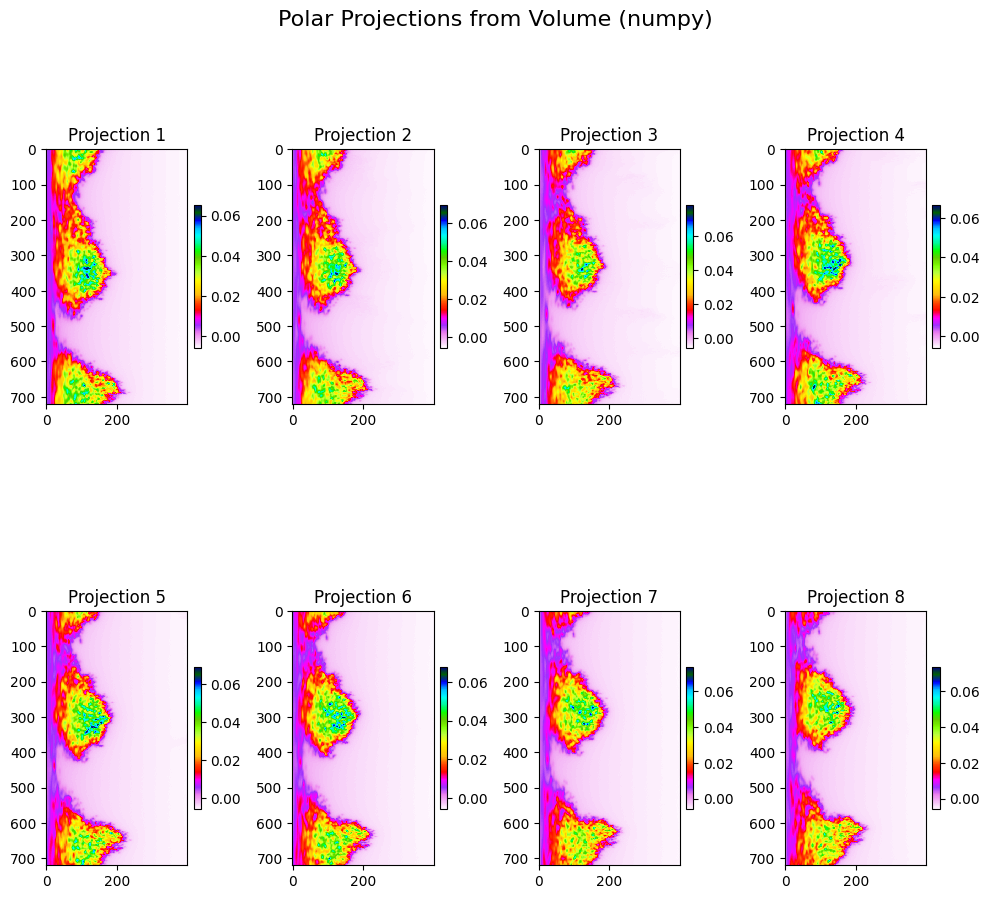

In [11]:
# Plot the first 16 projections
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(projections[i], cmap="gist_ncar_r", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")

fig.suptitle("Polar Projections from Volume (numpy)", fontsize=16)
plt.tight_layout()
plt.show()

### GPU (torch / cuCIM) results

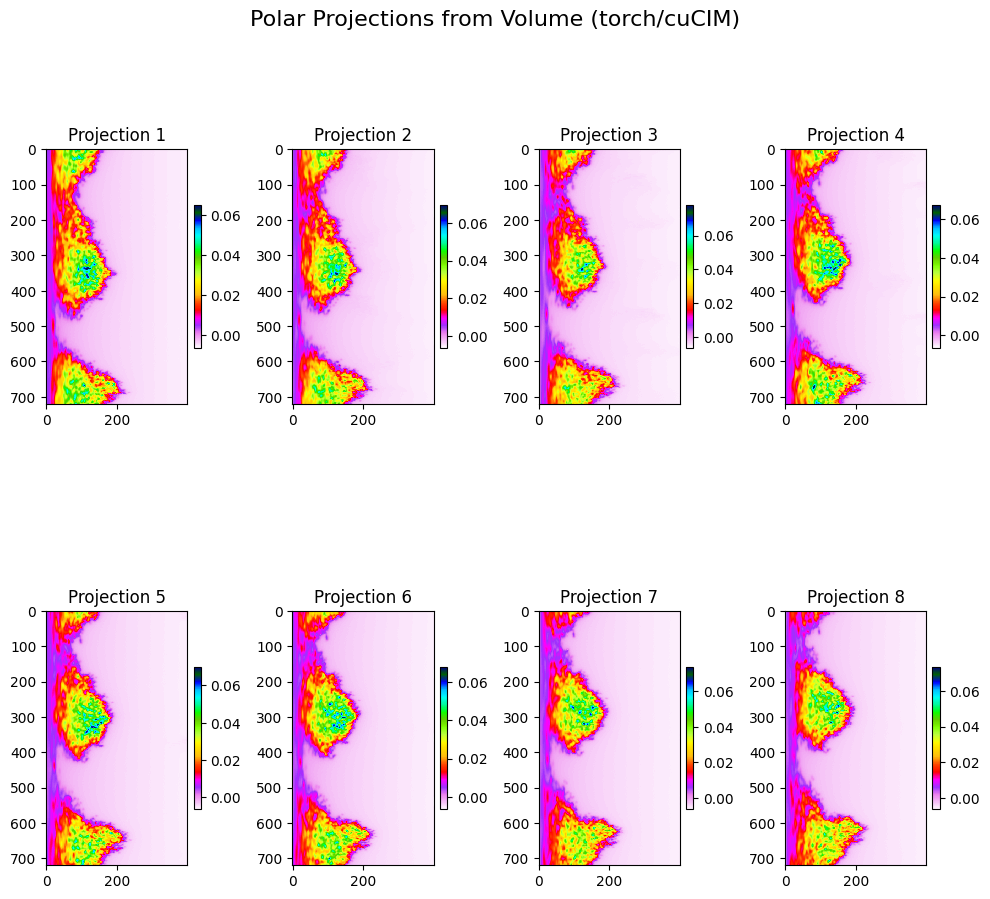

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(
        projections_gpu.cpu().numpy()[i], cmap="gist_ncar_r", interpolation="none"
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")

fig.suptitle("Polar Projections from Volume (torch/cuCIM)", fontsize=16)
plt.tight_layout()
plt.show()

### Difference between the two

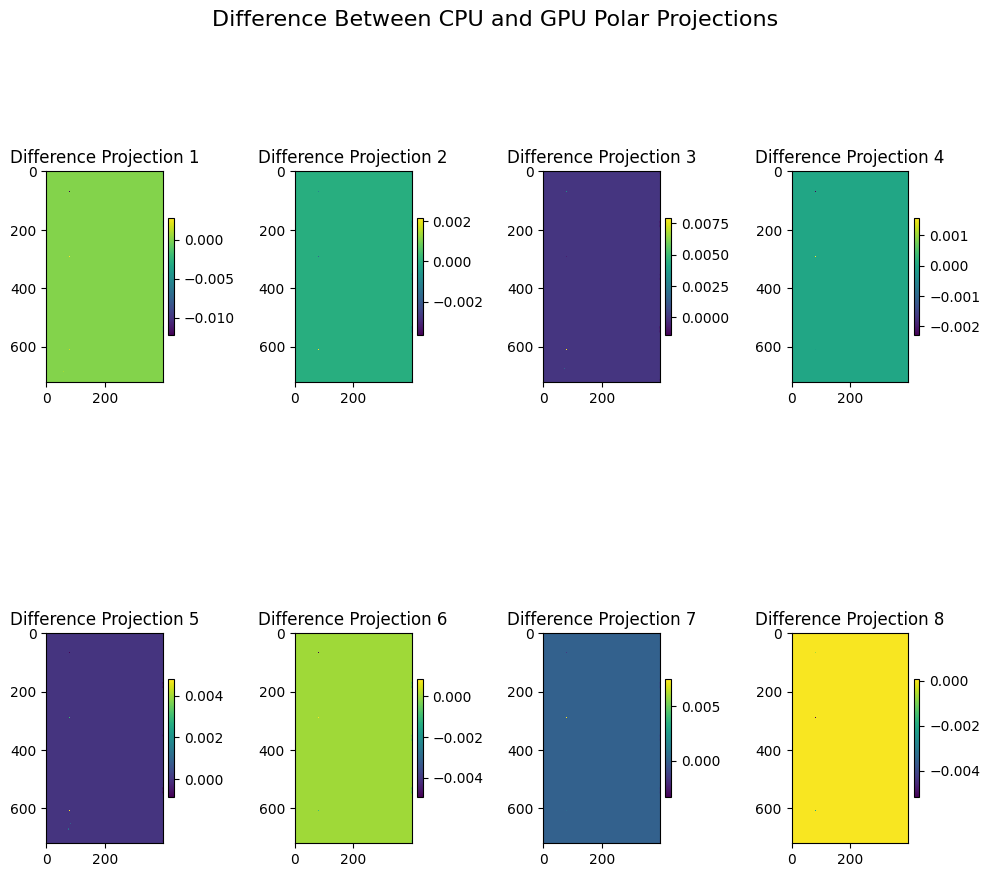

In [13]:
# Plot the difference between the two sets of polar projections
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    diff = projections_gpu.cpu().numpy()[i] - projections[i]
    im = ax.imshow(diff, interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Difference Projection {i + 1}")

fig.suptitle("Difference Between CPU and GPU Polar Projections", fontsize=16)
plt.tight_layout()
plt.show()

## Demonstrating inverse projection recovery

By applying `to_cartesian` (the inverse warp) we can recover the projections in Cartesian coordinate space. Because the transform instance already holds the full geometry (center, radius, image shape), no extra arguments are needed beyond the polar-space image itself.

In [14]:
inverse_projections = transformer.to_cartesian(projections)
inverse_projections.shape

(37, 256, 256)

In [15]:
inverse_projections_gpu = transformer.to_cartesian(projections_gpu)
inverse_projections_gpu.shape, inverse_projections_gpu.device

(torch.Size([37, 256, 256]), device(type='cuda', index=0))

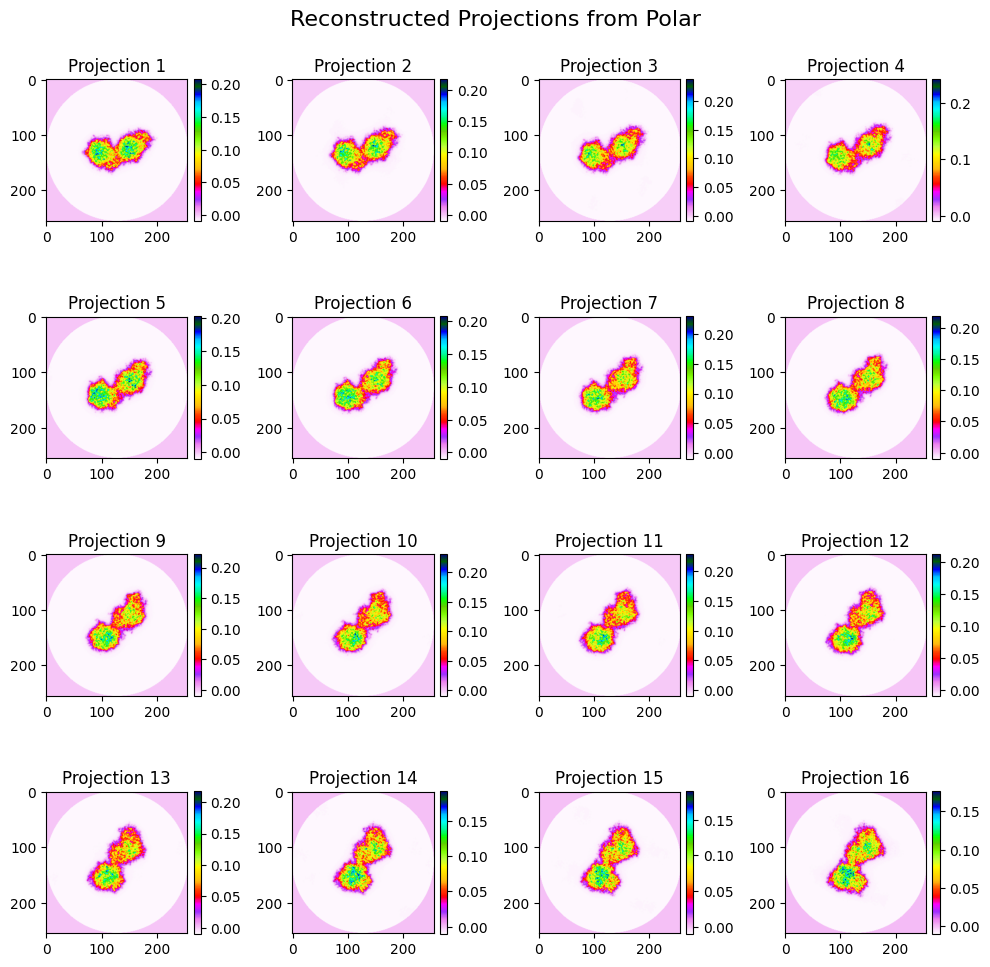

In [16]:
# Plot the first 16 reinverted projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(inverse_projections[i], cmap="gist_ncar_r")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()

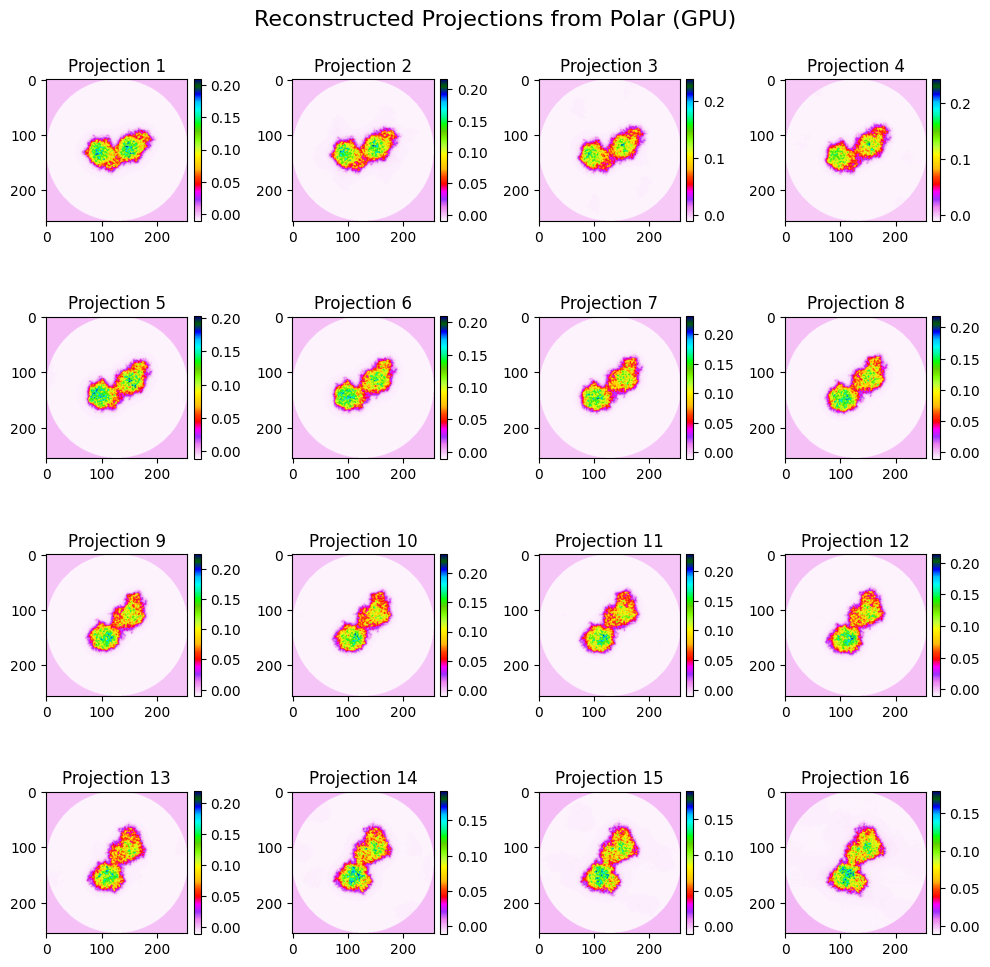

In [17]:
# Plot the first 16 reinverted projections (on GPU)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(inverse_projections_gpu[i].cpu().numpy(), cmap="gist_ncar_r")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar (GPU)", fontsize=16)
plt.tight_layout()
plt.show()

### Difference between this and ground-truth projections

/tmp/ipykernel_1729280/977202226.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = ground_truth_projections - inverse_projections


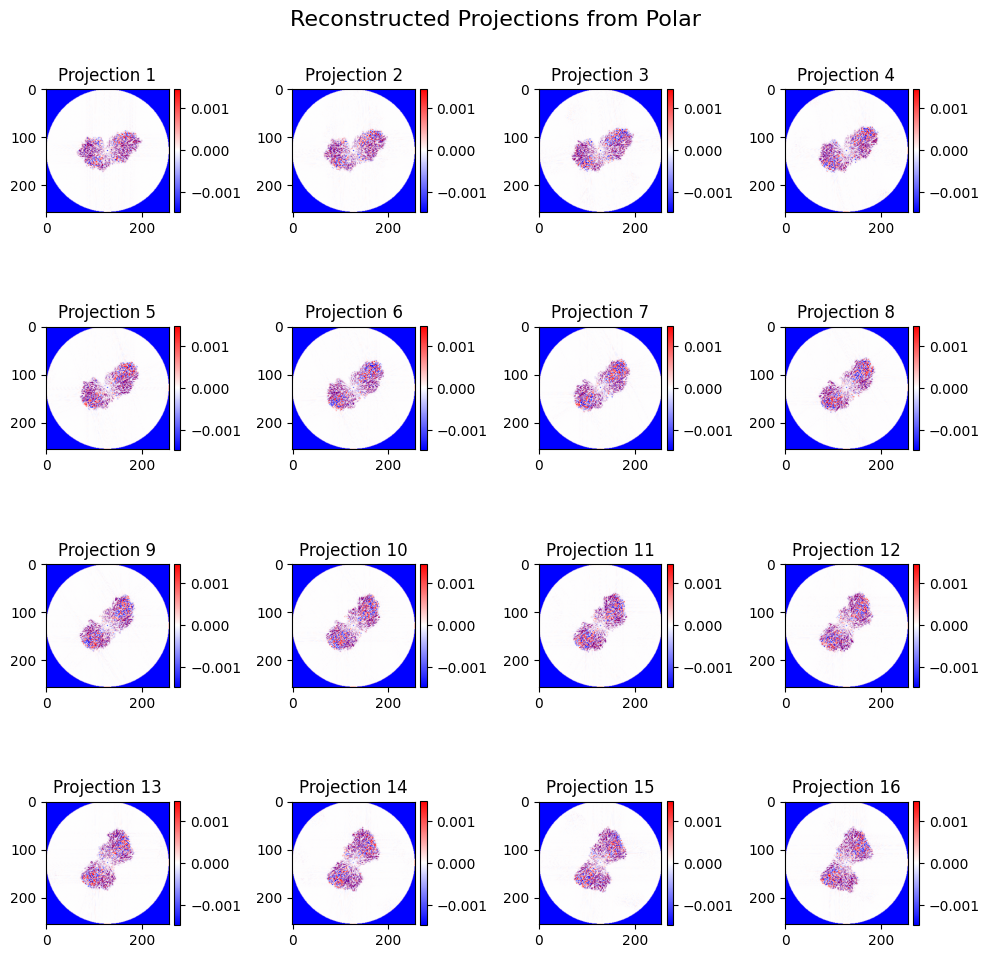

In [18]:
# Plot the differences of the first 16 reinverted projections with their ground-truth
diff = ground_truth_projections - inverse_projections
max_diff = diff.abs().max() * 0.1

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(diff[i], cmap="bwr", vmin=-max_diff, vmax=max_diff)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()